## Vanilla U-Net
### Overview
U-Net is a popular neural network architecture that has been widely used for image pixel-wise segmentation tasks, particularly in medical imaging and computer vision. It was first introduced in 2015 by Ronneberger et al. for biomedical image segmentation tasks.

### Architecture
The U-Net architecture consists of two main paths:

Contracting Path (Encoder): This path is responsible for downsampling the input image and extracting features at multiple scales. It consists of a series of convolutional and max-pooling layers, which reduce the spatial dimensions of the feature maps while increasing the number of channels.
Expansive Path (Decoder): This path is responsible for upsampling the feature maps and producing the final segmentation mask. It consists of a series of convolutional and upsampling layers, which increase the spatial dimensions of the feature maps while reducing the number of channels.
Key Components

Convolutional Blocks: The U-Net uses convolutional blocks, which consist of two convolutional layers with a ReLU activation function, followed by a batch normalization layer.
Max-Pooling Layers: The contracting path uses max-pooling layers to downsample the feature maps by a factor of 2.
Upsampling Layers: The expansive path uses upsampling layers to upsample the feature maps by a factor of 2. This is typically done using transposed convolutional layers or bilinear interpolation.
Skip Connections: The U-Net uses skip connections to concatenate feature maps from the contracting path with the corresponding feature maps in the expansive path. This helps to preserve spatial information and improve the accuracy of the segmentation.
Architecture Diagram

#### Layers Breakdown

```
Input Image (256x256)
|
|-- Conv Block 1 (32 filters)
|-- Max Pool 1 (128x128)
|-- Conv Block 2 (64 filters)
|-- Max Pool 2 (64x64)
|-- Conv Block 3 (128 filters)
|-- Max Pool 3 (32x32)
|-- Conv Block 4 (256 filters)
|-- Max Pool 4 (16x16)
|-- Conv Block 5 (512 filters)
|
|-- Upsampling 1 (32x32)
|-- Concatenate with Conv Block 4
|-- Conv Block 6 (256 filters)
|-- Upsampling 2 (64x64)
|-- Concatenate with Conv Block 3
|-- Conv Block 7 (128 filters)
|-- Upsampling 3 (128x128)
|-- Concatenate with Conv Block 2
|-- Conv Block 8 (64 filters)
|-- Upsampling 4 (256x256)
|-- Output (256x256)
```

### Reason for Selection
U-Net feels like a good starting point for experimentation. It was first introduced in 2015 and his since been heavily built upon and used as a foundation for all kinds of image related tasks (image generation, image classification and object detection). 

YOLOv8-Seg is actually build on U-Net, but its creater acknowledges that it isn't necessarily more performant for all tasks. The advantage of implementing it in PyTorch rather than using the ultralytics library is that we can more easily modify the network based on our experimental findings, giving us more flexibility. 

## [U-Net PyTorch Implementation](https://github.com/milesial/Pytorch-UNet) (credit [milesial](https://github.com/milesial) on GitHub)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## Constants

In [2]:
EXPERIMENT_NAME = "unet_vanilla"
IMAGE_HEIGHT = 500
IMAGE_WIDTH = 500
NUM_OF_CLASSES = 7
CLASS_NAMES = ['Building', 'Field', 'Forest', 'Grass', 'Power line', 'Road', 'Water']
WEIGHTS_DIR = '/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/weights/vanilla_unet'
TRAIN_DEVICE = device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 12
LEARNING_RATE = 1e-4

DATASET_PATH = '/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8'
TMP_DATASET_PATH = f'{DATASET_PATH}/.tmp_dataset_{EXPERIMENT_NAME}'

### Define the Model

In [3]:
""" Parts of the U-Net model """

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)



class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [4]:
""" Full assembly of the parts to form the complete network """

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 32))
        self.down1 = (Down(32, 64))
        self.down2 = (Down(64, 128))
        factor = 2 if bilinear else 1
        self.down3 = (Down(128, 256))
        # self.down4 = (Down(256, 512 // factor))
        # self.up1 = (Up(512, 256 // factor, bilinear))
        self.up1 = (Up(256, 128 // factor, bilinear))
        self.up2 = (Up(128, 64 // factor, bilinear))
        self.up3 = (Up(64, 32, bilinear))
        self.outc = (OutConv(32, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        # x5 = self.down4(x4)
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        # x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        # self.down4 = torch.utils.checkpoint(self.down4)
        # self.up1 = torch.utils.checkpoint(self.up1)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.outc = torch.utils.checkpoint(self.outc)

# class UNet(nn.Module):
#     def __init__(self, n_channels, n_classes, bilinear=False):
#         super(UNet, self).__init__()
#         self.n_channels = n_channels
#         self.n_classes = n_classes
#         self.bilinear = bilinear

#         self.inc = (DoubleConv(n_channels, 32))
#         self.down1 = (Down(32, 64))
#         self.down2 = (Down(64, 128))
#         self.down3 = (Down(128, 256))
#         factor = 2 if bilinear else 1
#         self.up1 = (Up(256, 128 // factor, bilinear))
#         self.up2 = (Up(128, 64 // factor, bilinear))
#         self.up3 = (Up(64, 32, bilinear))
#         self.outc = (OutConv(32, n_classes))

#     def forward(self, x):
#         x1 = self.inc(x)
#         x2 = self.down1(x1)
#         x3 = self.down2(x2)
#         x4 = self.down3(x3)
#         x = self.up1(x4, x3)
#         x = self.up2(x, x2)
#         x = self.up3(x, x1)
#         logits = self.outc(x)
#         return logits

#     def use_checkpointing(self):
#         self.inc = torch.utils.checkpoint(self.inc)
#         self.down1 = torch.utils.checkpoint(self.down1)
#         self.down2 = torch.utils.checkpoint(self.down2)
#         self.down3 = torch.utils.checkpoint(self.down3)
#         self.up1 = torch.utils.checkpoint(self.up1)
#         self.up2 = torch.utils.checkpoint(self.up2)
#         self.up3 = torch.utils.checkpoint(self.up3)
#         self.outc = torch.utils.checkpoint(self.outc)

## Prepare Dataset

In [5]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from torchvision.io import read_image
import sys
parentdir = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, parentdir)
from utils.AerialDataset import AerialDataset
from utils.load_aerial_dataset import load_dataset

In [6]:
# load_dataset(DATASET_PATH, TMP_DATASET_PATH, IMAGE_HEIGHT, IMAGE_WIDTH, NUM_OF_CLASSES)
dataset_ids = load_dataset(DATASET_PATH, TMP_DATASET_PATH, IMAGE_HEIGHT, IMAGE_WIDTH, NUM_OF_CLASSES, generate_data=False)

## Check generated data

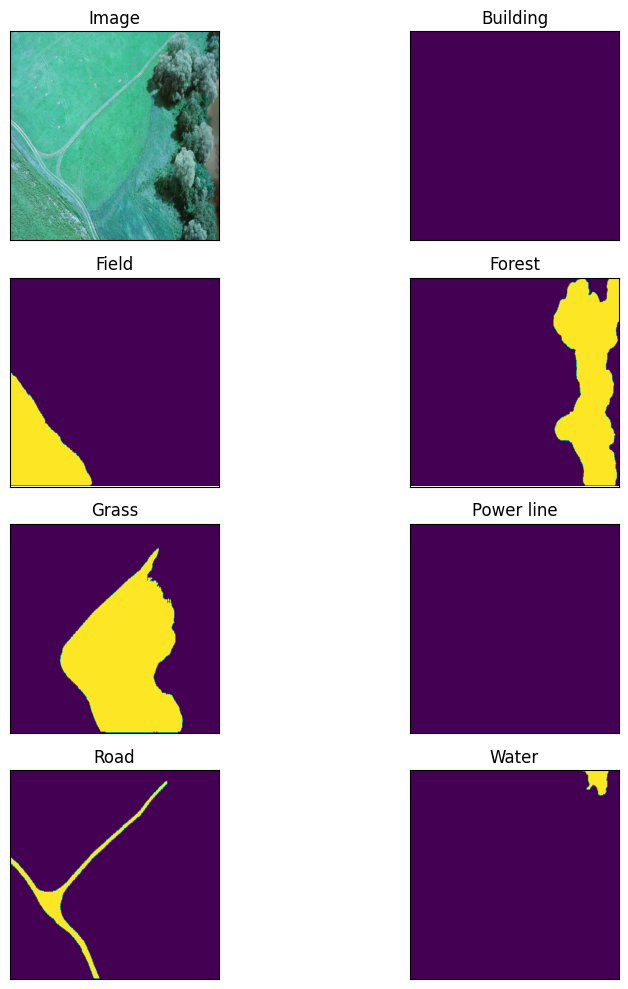

In [7]:
# Grab random label from dataset
labels = [TMP_DATASET_PATH + '/' + x for x in os.listdir(TMP_DATASET_PATH) if "__LABEL__" in x]
random_label = random.choice(labels)

# Get matching image
image_path = random_label.replace("__LABEL__", "__IMAGE__")

if image_path is None:
    print(f"No matching image for label {random_label}")
    sys.exit()

image = np.load(image_path)

label_image = np.load(random_label)

fig, axs = plt.subplots(int(NUM_OF_CLASSES**0.5+2), int(NUM_OF_CLASSES**0.5), figsize=(10, 10))

# Plot the images on the subplots
axs[0, 0].imshow(image)
axs[0, 0].set_title("Image")

for i in range(0, NUM_OF_CLASSES):
    
    axs[(i + 1) // int(NUM_OF_CLASSES**0.5), (i + 1) % int(NUM_OF_CLASSES**0.5)].imshow(label_image[:,:,i])
    axs[(i + 1) // int(NUM_OF_CLASSES**0.5), (i + 1) % int(NUM_OF_CLASSES**0.5)].set_title(CLASS_NAMES[i])
    


# Remove the axis ticks and labels
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

# Layout so plots do not overlap
fig.tight_layout()

# Show the plot
plt.show()

## Model train & eval code (once again credit [milesial](https://github.com/milesial))

In [8]:
from torch.utils.data import DataLoader, random_split
from torch import Tensor, optim
from tqdm import tqdm
import logging
from pathlib import Path
import time

In [9]:
def dice_coeff(input: Tensor, target: Tensor, reduce_batch_first: bool = False, epsilon: float = 1e-6):
    # Average of Dice coefficient for all batches, or for a single mask
    assert input.size() == target.size()
    assert input.dim() == 3 or not reduce_batch_first

    sum_dim = (-1, -2) if input.dim() == 2 or not reduce_batch_first else (-1, -2, -3)

    inter = 2 * (input * target).sum(dim=sum_dim)
    sets_sum = input.sum(dim=sum_dim) + target.sum(dim=sum_dim)
    sets_sum = torch.where(sets_sum == 0, inter, sets_sum)

    dice = (inter + epsilon) / (sets_sum + epsilon)
    return dice.mean()


def multiclass_dice_coeff(input: Tensor, target: Tensor, reduce_batch_first: bool = False, epsilon: float = 1e-6):
    # Average of Dice coefficient for all classes
    return dice_coeff(input.flatten(0, 1), target.flatten(0, 1), reduce_batch_first, epsilon)


def dice_loss(input: Tensor, target: Tensor, multiclass: bool = False):
    # Dice loss (objective to minimize) between 0 and 1
    fn = multiclass_dice_coeff if multiclass else dice_coeff
    return 1 - fn(input, target, reduce_batch_first=True)

In [10]:
@torch.inference_mode()
def evaluate(net, dataloader, device, amp):
    net.eval()
    num_val_batches = len(dataloader)
    dice_score = 0
    
    print("Evaluating model...")

    # iterate over the validation set
    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
        for batch in tqdm(dataloader, total=num_val_batches, desc='Validation round', unit='batch', leave=False):
            image, mask_true = batch['image'], batch['mask']

            # move images and labels to correct device and type
            image = image.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            mask_true = mask_true.to(device=device, dtype=torch.long)

            # predict the mask
            mask_pred = net(image)

            if net.n_classes == 1:
                assert mask_true.min() >= 0 and mask_true.max() <= 1, 'True mask indices should be in [0, 1]'
                mask_pred = (F.sigmoid(mask_pred) > 0.5).float()
                # compute the Dice score
                dice_score += dice_coeff(mask_pred, mask_true, reduce_batch_first=False)
            else:
                assert mask_true.min() >= 0 and mask_true.max() < net.n_classes, 'True mask indices should be in [0, n_classes]'
                # convert to one-hot format
                # mask_true = F.one_hot(mask_true, net.n_classes).permute(0, 3, 1, 2).float()
                # mask_pred = F.one_hot(mask_pred.argmax(dim=1), net.n_classes).permute(0, 3, 1, 2).float()
                mask_true = mask_true.permute(0, 3, 1, 2).float()
                mask_pred = mask_pred.permute(0, 3, 1, 2).float()
                # compute the Dice score, ignoring background
                dice_score += multiclass_dice_coeff(mask_pred[:, 1:], mask_true[:, 1:], reduce_batch_first=False)

    net.train()
    return dice_score / max(num_val_batches, 1)

In [11]:
dataset = AerialDataset(TMP_DATASET_PATH, dataset_ids, IMAGE_WIDTH=IMAGE_WIDTH, IMAGE_HEIGHT=IMAGE_HEIGHT)

# 2. Split into train / validation partitions
n_val = int(len(dataset) * 0.1)
n_train = len(dataset) - n_val
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

In [12]:
# img = np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/' + train_set.dataset.ids[0] + "__LABEL__.npy")
# plt.imshow(img[:,:,6])
# plt.show()

In [13]:
def train_model(
        model,
        device,
        epochs: int = 5,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        val_percent: float = 0.1,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
):
    # 1. Create dataset
    dataset = AerialDataset(TMP_DATASET_PATH, dataset_ids, IMAGE_WIDTH=IMAGE_WIDTH, IMAGE_HEIGHT=IMAGE_HEIGHT)

    # 2. Split into train / validation partitions
    n_val = int(len(dataset) * val_percent)
    n_train = len(dataset) - n_val
    train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

    # 3. Create data loaders
    loader_args = dict(batch_size=batch_size, num_workers=os.cpu_count(), pin_memory=True)
    train_loader = DataLoader(train_set, shuffle=True, **loader_args)
    val_loader = DataLoader(val_set, shuffle=False, drop_last=True, **loader_args)

    logging.info(f'''Starting training:
        Epochs:          {epochs}
        Batch size:      {batch_size}
        Learning rate:   {learning_rate}
        Training size:   {n_train}
        Validation size: {n_val}
        Checkpoints:     {save_checkpoint}
        Device:          {device.type}
        Images scaling:  {img_scale}
        Mixed Precision: {amp}
    ''')

    # 4. Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
    optimizer = optim.RMSprop(model.parameters(),
                              lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=False)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5) # goal: maximize Dice score
    # grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
    criterion = nn.CrossEntropyLoss()
    global_step = 0

    # 5. Begin training
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        epoch_step = 0
        with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
            for batch in train_loader:
                images, true_masks = batch['image'], batch['mask']

                assert images.shape[1] == model.n_channels, \
                    f'Network has been defined with {model.n_channels} input channels, ' \
                    f'but loaded images have {images.shape[1]} channels. Please check that ' \
                    'the images are loaded correctly.'

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                true_masks = true_masks.to(device=device, dtype=torch.long)

                with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                    masks_pred = model(images)
                    if model.n_classes == 1:
                        loss = criterion(masks_pred.squeeze(1), true_masks.float())
                        loss += dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                    else:
                        loss = criterion(masks_pred, true_masks.float())
                        loss += dice_loss(
                            F.softmax(masks_pred, dim=1).float(),
                            true_masks.permute(0, 1, 3, 2).float(),
                            multiclass=True
                        )

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                
                optimizer.step()
                
                
                # grad_scaler.scale(loss).backward()
                # grad_scaler.unscale_(optimizer)
                # torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                # grad_scaler.step(optimizer)
                # grad_scaler.update()

                pbar.update(images.shape[0])
                global_step += 1
                epoch_step += 1
                epoch_loss += loss.item()
                
                running_epoch_loss = epoch_loss/epoch_step
                pbar.set_postfix(**{'loss (batch)': loss.item()})

                # Evaluation round
                division_step = (n_train // (10 * batch_size))
                if division_step > 0:
                    if global_step % division_step == 0:
                        img = np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/ik_4_00201_png.rf.1fb07bc291af61b5352db5cdcbc7bc97__IMAGE__.npy')
                        img = img.reshape((3,500,500))
                        img = torch.tensor([img])
                        img = img.to(device=device, dtype=torch.float32)
                        mask = model(img)
                        mask = Tensor.cpu(mask)
                        
                        img = np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/ik_4_00201_png.rf.1fb07bc291af61b5352db5cdcbc7bc97__IMAGE__.npy')

                        # Plot the images on the subplots
                        label_image = mask.detach().numpy().reshape(7,500,500)[1,:,:]
                        
                        # fig, axs = plt.subplots(int(NUM_OF_CLASSES**0.5+2), int(NUM_OF_CLASSES**0.5), figsize=(10, 10))
                        fig, axs = plt.subplots(1, 3, figsize=(10, 10))

                        # Plot the images on the subplots
                        axs[0].imshow(img)
                        axs[0].set_title("Input")
                        
                        # for i in range(0, NUM_OF_CLASSES):
                        #     axs[(i + 1) // int(NUM_OF_CLASSES**0.5), (i + 1) % int(NUM_OF_CLASSES**0.5)].imshow(label_image[:,:,i])
                        #     axs[(i + 1) // int(NUM_OF_CLASSES**0.5), (i + 1) % int(NUM_OF_CLASSES**0.5)].set_title(CLASS_NAMES[i])
                        axs[1].imshow(label_image)
                        axs[1].set_title("MASK")
                        
                        axs[2].imshow(np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/ik_4_00201_png.rf.1fb07bc291af61b5352db5cdcbc7bc97__LABEL__.npy').reshape(500,500, 7)[:,:,1])

                        # Remove the axis ticks and labels
                        for ax in axs.flat:
                            ax.set_xticks([])
                            ax.set_yticks([])

                        # Layout so plots do not overlap
                        fig.tight_layout()

                        # Show the plot
                        plt.show()

                        # Path(WEIGHTS_DIR).mkdir(parents=True, exist_ok=True)
                        # state_dict = model.state_dict()
                        # torch.save(state_dict, str(WEIGHTS_DIR + '/{}_{}_checkpoint_epoch{}_step{}.pth'.format(int(time.time()), EXPERIMENT_NAME, epoch, global_step)))
                        # logging.info(f'Checkpoint {epoch} saved!')
                        # val_score = evaluate(model, val_loader, device, amp)
                        # scheduler.step(val_score)

                        # logging.info('Validation Dice score: {}'.format(val_score))
                        # try:
                        #     print({
                        #         'learning rate': optimizer.param_groups[0]['lr'],
                        #         'validation Dice': val_score,
                        #         'step': global_step,
                        #         'epoch': epoch,
                        #     })
                        # except:
                        #     pass

        if save_checkpoint:
            Path(WEIGHTS_DIR).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            torch.save(state_dict, str(WEIGHTS_DIR + '/{}_checkpoint_epoch{}.pth'.format(EXPERIMENT_NAME, epoch)))
            logging.info(f'Checkpoint {epoch} saved!')

## Train model!

In [14]:
model = UNet(n_channels=3, n_classes=NUM_OF_CLASSES, bilinear=False)
model = model.to(memory_format=torch.channels_last)
logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')
model.to(device=TRAIN_DEVICE)

train_model(
            model=model,
            epochs=10,
            # batch_size=BATCH_SIZE,
            batch_size=8,
            learning_rate=LEARNING_RATE,
            device=TRAIN_DEVICE,
            img_scale=0.5,
            val_percent=0.1,
            amp=False
        )

Epoch 1/10:  10%|▉         | 240/2426 [00:37<05:05,  7.15img/s, loss (batch)=1.23]/var/folders/ml/7nl4w1jn5j9_p1j7lhbknxzc0000gn/T/ipykernel_50707/1140876401.py:105: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  img = torch.tensor([img])


## Clean things up

In [ ]:
# shutil.rmtree(TMP_DATASET_PATH)

In [ ]:
model = UNet(n_channels=3, n_classes=NUM_OF_CLASSES, bilinear=False)
model.load_state_dict(torch.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/weights/vanilla_unet/unet_vanilla_checkpoint_epoch1.pth'))
model.to(device)

/var/folders/ml/7nl4w1jn5j9_p1j7lhbknxzc0000gn/T/ipykernel_57754/4195951392.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/Users/cono

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     

In [ ]:
img = np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/alina_139_jpg.rf.831ce983aa542955a40b555b51e86cb6__IMAGE__.npy')
img = img.reshape((3,500,500))
img = torch.tensor([img])
img = img.to(device=device, dtype=torch.float32)
mask = model(img)
mask = Tensor.cpu(mask)

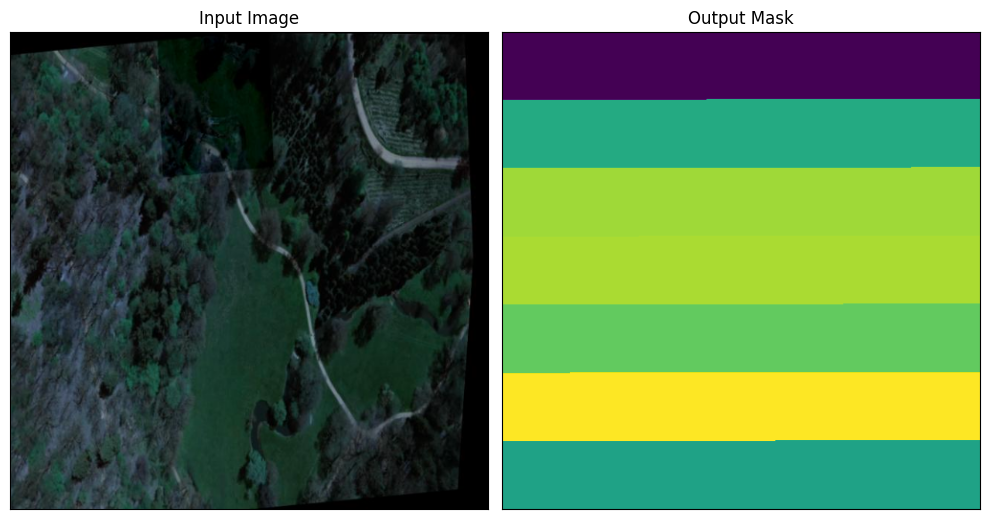

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

# Plot the images on the subplots
axs[0].imshow(np.load('/Users/conor/Development/AeroSoc/Payload/AI-utils/sznet/datasets/aerial_dataset.yolov8/.tmp_dataset_unet_vanilla/alina_139_jpg.rf.831ce983aa542955a40b555b51e86cb6__IMAGE__.npy'))
axs[0].set_title("Input Image")

axs[1].imshow(mask.detach().numpy().reshape(500,500,7)[:,:,4])
axs[1].set_title("Output Mask")


# Remove the axis ticks and labels
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

# Layout so plots do not overlap
fig.tight_layout()

# Show the plot
plt.show()
